In [84]:
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

In [67]:
from dotenv import load_dotenv
load_dotenv()

True

In [68]:
data_dir = os.getenv("DATA_DIR")
datasplits_dir = os.getenv("DATASPLITS_DIR")
embeddings_dir = os.getenv("EMBEDDINGS_DIR")

text_train_path = os.path.join(datasplits_dir, "text_train.tsv")
text_val_path = os.path.join(datasplits_dir, "text_val.tsv")
text_test_path = os.path.join(datasplits_dir, "text_test.tsv")

train_bert_path = os.path.join(embeddings_dir, "train_bert.npy")
val_bert_path = os.path.join(embeddings_dir, "val_bert.npy")
test_bert_path = os.path.join(embeddings_dir, "test_bert.npy")

train_roberta_path = os.path.join(embeddings_dir, "train_roberta.npy")
val_roberta_path = os.path.join(embeddings_dir, "val_roberta.npy")
test_roberta_path = os.path.join(embeddings_dir, "test_roberta.npy")

train_bertweet_path = os.path.join(embeddings_dir, "train_bertweet.npy")
val_bertweet_path = os.path.join(embeddings_dir, "val_bertweet.npy")
test_bertweet_path = os.path.join(embeddings_dir, "test_bertweet.npy")

In [69]:
train_bert = np.load(train_bert_path)
val_bert = np.load(val_bert_path)
test_bert = np.load(test_bert_path)

train_roberta = np.load(train_roberta_path)
val_roberta = np.load(val_roberta_path)
test_roberta = np.load(test_roberta_path)

train_bertweet = np.load(train_bertweet_path)
val_bertweet = np.load(val_bertweet_path)
test_bertweet = np.load(test_bertweet_path)

In [80]:

text_train_df = pd.read_csv(text_train_path, sep='\t')
text_val_df = pd.read_csv(text_val_path, sep='\t')
text_test_df = pd.read_csv(text_test_path, sep='\t')

print(f"text train set size: {len(text_train_df)}")
print(f"text val set size: {len(text_val_df)}")
print(f"text test set size: {len(text_test_df)}")

text_train_df.head()

text train set size: 11240
text val set size: 2409
text test set size: 2409


,tweet_text,text_info,text_human,cleaned_text_bert,cleaned_text_bertweet
0,Good to see supplies from #chinaaid reaching t...,informative,rescue_volunteering_or_donation_effort,Good to see supplies from chinaaid reaching th...,Good to see supplies from #chinaaid reaching t...
1,Harvey to Impact North Texas Construction Indu...,informative,infrastructure_and_utility_damage,Harvey to Impact North Texas Construction Indu...,Harvey to Impact North Texas Construction Indu...
2,Took granddaughters back to school in Mexico C...,not_informative,not_humanitarian,Took granddaughters back to school in Mexico C...,Took granddaughters back to school in Mexico C...
3,"NEWS: At least 200 people, including 21 childr...",informative,affected_individuals,"NEWS: At least 200 people, including 21 childr...","NEWS: At least 200 people, including 21 childr..."
4,Press Release: Citizens to open additional Cat...,informative,rescue_volunteering_or_donation_effort,Press Release: Citizens to open additional Cat...,Press Release: Citizens to open additional Cat...


In [71]:
#Task 1: Binary (text_info)
le_info = LabelEncoder()
le_info.fit(text_train_df["text_info"])  # Adatta solo sul train

train_labels_task1 = le_info.transform(text_train_df["text_info"])
val_labels_task1 = le_info.transform(text_val_df["text_info"])
test_labels_task1 = le_info.transform(text_test_df["text_info"])

#Task 2: Multiclasse (text_human)
le_human = LabelEncoder()
le_human.fit(text_train_df["text_human"])

train_labels_task2 = le_human.transform(text_train_df["text_human"])
val_labels_task2 = le_human.transform(text_val_df["text_human"])
test_labels_task2 = le_human.transform(text_test_df["text_human"])

#Mapping classi e label
print("Task 1 classes:", dict(zip(le_info.classes_, le_info.transform(le_info.classes_))))
print("Task 2 classes:", dict(zip(le_human.classes_, le_human.transform(le_human.classes_))))

Task 1 classes: {'informative': np.int64(0), 'not_informative': np.int64(1)}
Task 2 classes: {'affected_individuals': np.int64(0), 'infrastructure_and_utility_damage': np.int64(1), 'not_humanitarian': np.int64(2), 'other_relevant_information': np.int64(3), 'rescue_volunteering_or_donation_effort': np.int64(4)}


In [72]:
def create_mlp(input_dim, output_dim, is_binary):
    
    input = keras.Input(shape=(input_dim,))

    x = layers.Dense(512, activation='relu')(input)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(output_dim, activation='sigmoid' if is_binary else 'softmax')(x)
    model = keras.Model(inputs=input, outputs=output)

    model.compile(
        loss='binary_crossentropy' if is_binary else 'categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    
    return model

In [73]:
def plot_training_history(history, title="Model Training"):
    """
    Plot accuracy and loss curves for training and validation.

    Parameters:
        history (History): Keras History object returned by model.fit()
        title (str): Title prefix for the plots
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [74]:
def train_and_evaluate(name, X_train, y_train, X_val, y_val, X_test, y_test, task=1, label_encoder=None):
    is_binary = (task == 1)
    y_train_enc = y_train if is_binary else to_categorical(y_train)
    y_val_enc = y_val if is_binary else to_categorical(y_val)
    
    model = create_mlp(X_train.shape[1], 1 if is_binary else y_train_enc.shape[1], is_binary)
    print(f"\n🚀 Training MLP on {name.upper()} embeddings (Task {task})")

    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train_enc,
        validation_data=(X_val, y_val_enc),
        epochs=50,
        batch_size=32,
        callbacks=[es],
    )

    plot_training_history(history, title=f"{name.upper()} - Task {task}")
    
    y_pred = model.predict(X_test)
    y_pred_labels = (y_pred > 0.5).astype(int).flatten() if is_binary else np.argmax(y_pred, axis=1)

    # 📊 Report metriche
    acc = accuracy_score(y_test, y_pred_labels)
    avg_type = 'binary' if is_binary else 'macro'
    prec = precision_score(y_test, y_pred_labels, average=avg_type, zero_division=0)
    rec = recall_score(y_test, y_pred_labels, average=avg_type, zero_division=0)
    f1 = f1_score(y_test, y_pred_labels, average=avg_type, zero_division=0)

    print(f"\n📊 Results for {name.upper()} - Task {task}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # 🧩 Matrice di confusione
    if label_encoder:
        display_labels = label_encoder.classes_
    else:
        display_labels = None

    cm = confusion_matrix(y_test, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap='Blues')
    if not is_binary:
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

    plt.title(f"Confusion Matrix - {name.upper()} - Task {task}", )
    plt.show()

In [75]:
embedding_sets = {
    "bert": {
        "train": train_bert,
        "val": val_bert,
        "test": test_bert
    },
    "roberta": {
        "train": train_roberta,
        "val": val_roberta,
        "test": test_roberta
    },
    "bertweet": {
        "train": train_bertweet,
        "val": val_bertweet,
        "test": test_bertweet
    }
}


🚀 Training MLP on BERT embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7626 - loss: 0.5024 - val_accuracy: 0.8132 - val_loss: 0.4153
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8057 - loss: 0.4288 - val_accuracy: 0.8132 - val_loss: 0.4110
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8172 - loss: 0.4130 - val_accuracy: 0.8157 - val_loss: 0.4054
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8319 - loss: 0.3933 - val_accuracy: 0.7597 - val_loss: 0.4800
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8269 - loss: 0.3998 - val_accuracy: 0.8153 - val_loss: 0.4165
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8313 - loss: 0.3872 - val_accuracy: 0.7962 - val_loss: 0.4419
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8355 - loss: 0.3757 - val_accuracy: 0.8128 - val_loss: 0.4088
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accura

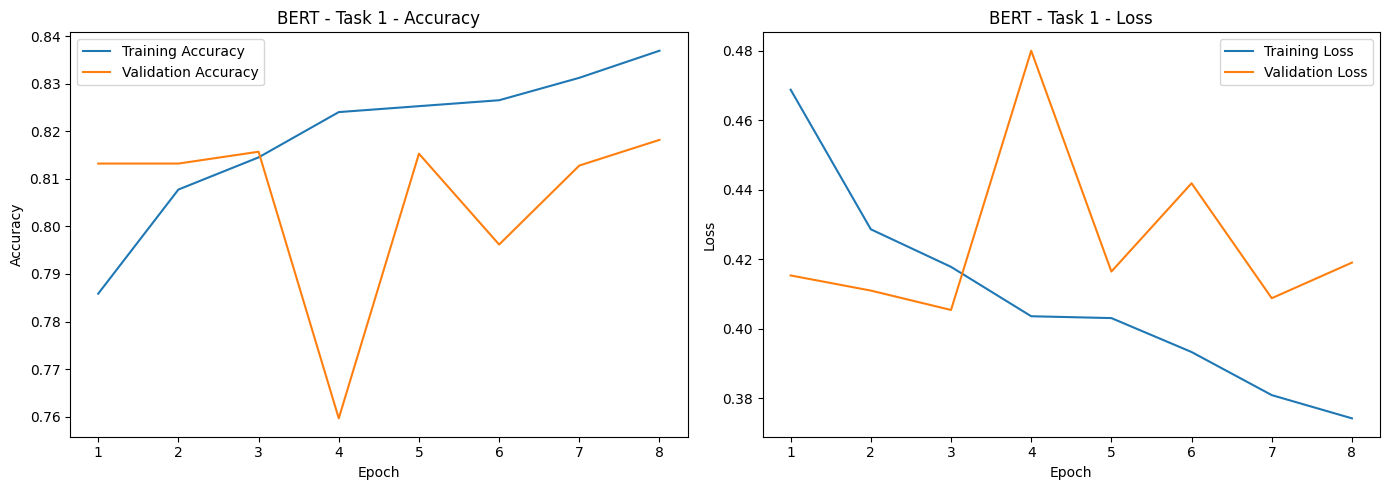

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

📊 Results for BERT - Task 1
Accuracy : 0.8194
Precision: 0.7470
Recall   : 0.5490
F1-score : 0.6329


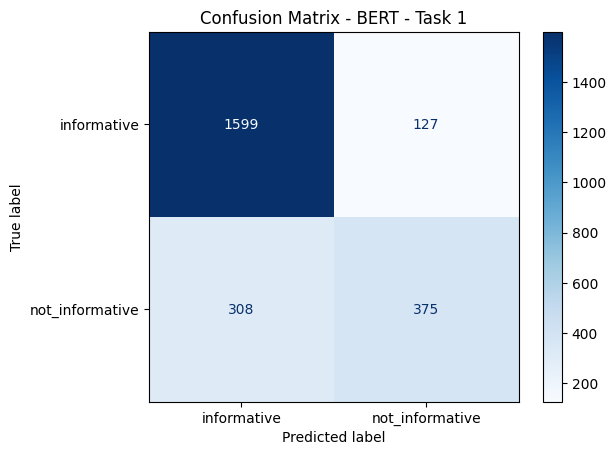


🚀 Training MLP on BERT embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5165 - loss: 1.2071 - val_accuracy: 0.5778 - val_loss: 1.0332
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6102 - loss: 0.9767 - val_accuracy: 0.6285 - val_loss: 0.9477
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6323 - loss: 0.9376 - val_accuracy: 0.6389 - val_loss: 0.9143
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6459 - loss: 0.8970 - val_accuracy: 0.6380 - val_loss: 0.9048
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6600 - loss: 0.8677 - val_accuracy: 0.6438 - val_loss: 0.8938
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6647 - loss: 0.8454 - val_accuracy: 0.6177 - val_loss: 0.9075
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6731 - loss: 0.8262 - val_accuracy: 0.6343 - val_loss: 0.9106
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accura

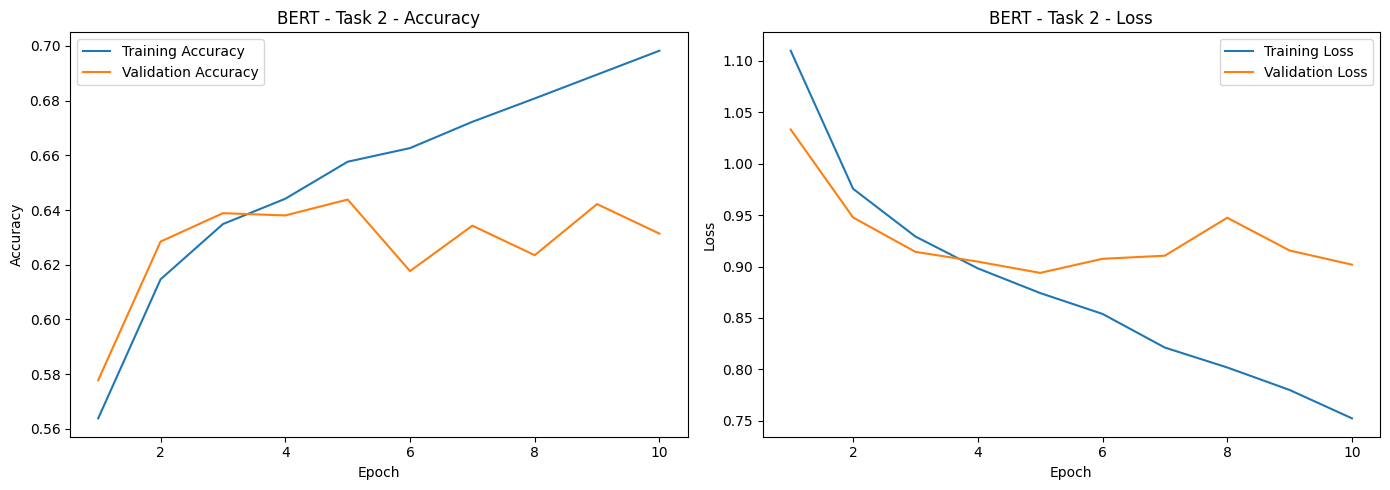

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERT - Task 2
Accuracy : 0.6588
Precision: 0.6261
Recall   : 0.6166
F1-score : 0.6181


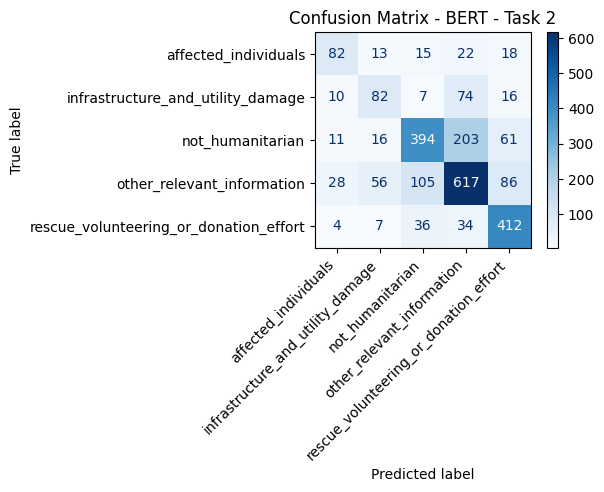

In [76]:
name = "bert"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1, label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2, label_encoder=le_human)


🚀 Training MLP on ROBERTA embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7604 - loss: 0.5209 - val_accuracy: 0.8232 - val_loss: 0.4064
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8219 - loss: 0.4152 - val_accuracy: 0.8261 - val_loss: 0.4095
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8158 - loss: 0.4198 - val_accuracy: 0.8219 - val_loss: 0.4013
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8176 - loss: 0.4173 - val_accuracy: 0.8215 - val_loss: 0.4041
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8216 - loss: 0.4081 - val_accuracy: 0.8182 - val_loss: 0.4063
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8347 - loss: 0.3899 - val_accuracy: 0.8298 - val_loss: 0.3928
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8215 - loss: 0.3983 - val_accuracy: 0.8248 - val_loss: 0.4054
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc

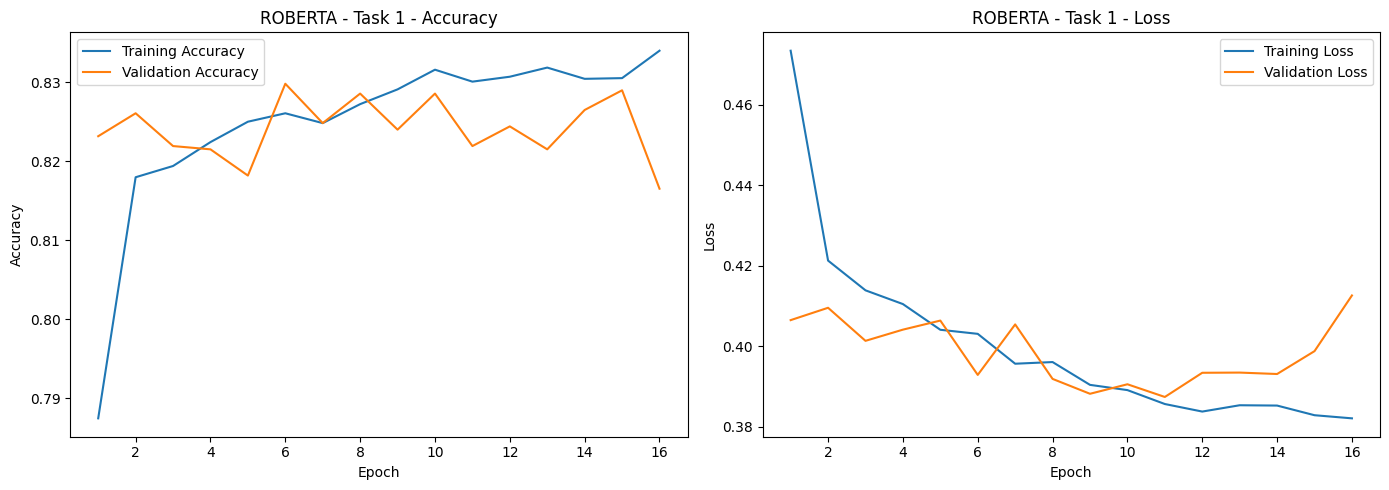

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for ROBERTA - Task 1
Accuracy : 0.8269
Precision: 0.7409
Recall   : 0.5988
F1-score : 0.6623


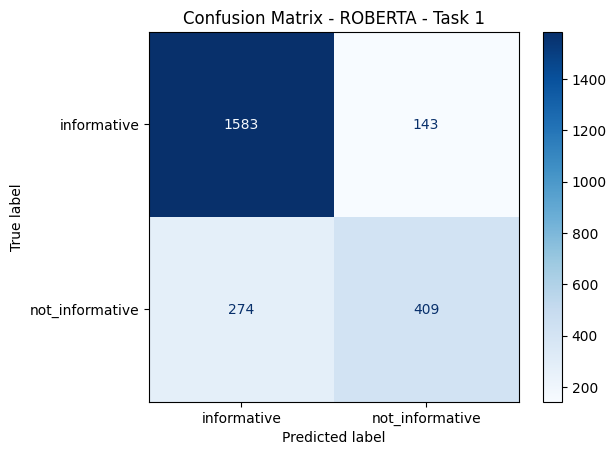


🚀 Training MLP on ROBERTA embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4593 - loss: 1.3028 - val_accuracy: 0.6214 - val_loss: 0.9554
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6223 - loss: 0.9730 - val_accuracy: 0.6459 - val_loss: 0.9013
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6435 - loss: 0.9157 - val_accuracy: 0.6687 - val_loss: 0.8630
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6472 - loss: 0.9002 - val_accuracy: 0.6467 - val_loss: 0.8930
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6547 - loss: 0.8723 - val_accuracy: 0.6629 - val_loss: 0.8449
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6659 - loss: 0.8501 - val_accuracy: 0.6633 - val_loss: 0.8393
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6682 - loss: 0.8487 - val_accuracy: 0.6704 - val_loss: 0.8386
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc

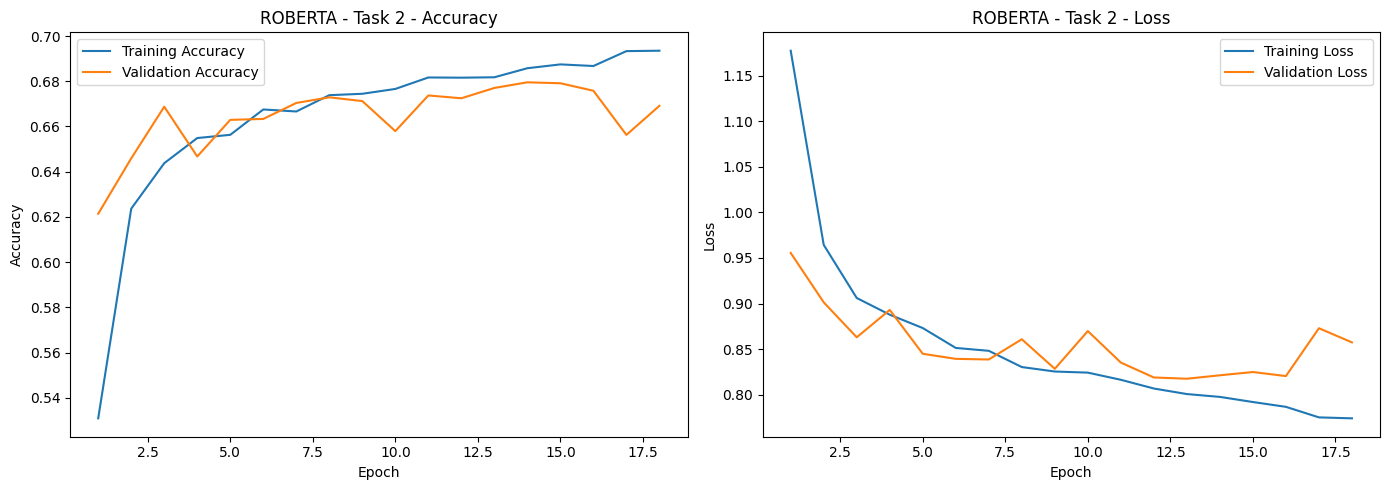

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for ROBERTA - Task 2
Accuracy : 0.6907
Precision: 0.6669
Recall   : 0.6314
F1-score : 0.6406


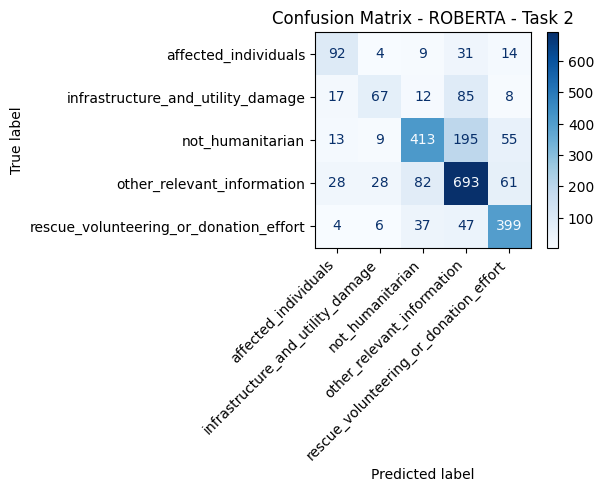

In [77]:
name = "roberta"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1,label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2,label_encoder=le_human)


🚀 Training MLP on BERTWEET embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7478 - loss: 0.5278 - val_accuracy: 0.8082 - val_loss: 0.4421
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8034 - loss: 0.4474 - val_accuracy: 0.7954 - val_loss: 0.4531
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7984 - loss: 0.4466 - val_accuracy: 0.8061 - val_loss: 0.4309
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8094 - loss: 0.4292 - val_accuracy: 0.8203 - val_loss: 0.4156
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8088 - loss: 0.4277 - val_accuracy: 0.8227 - val_loss: 0.4118
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8117 - loss: 0.4275 - val_accuracy: 0.8194 - val_loss: 0.4127
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8126 - loss: 0.4159 - val_accuracy: 0.8215 - val_loss: 0.4121
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - ac

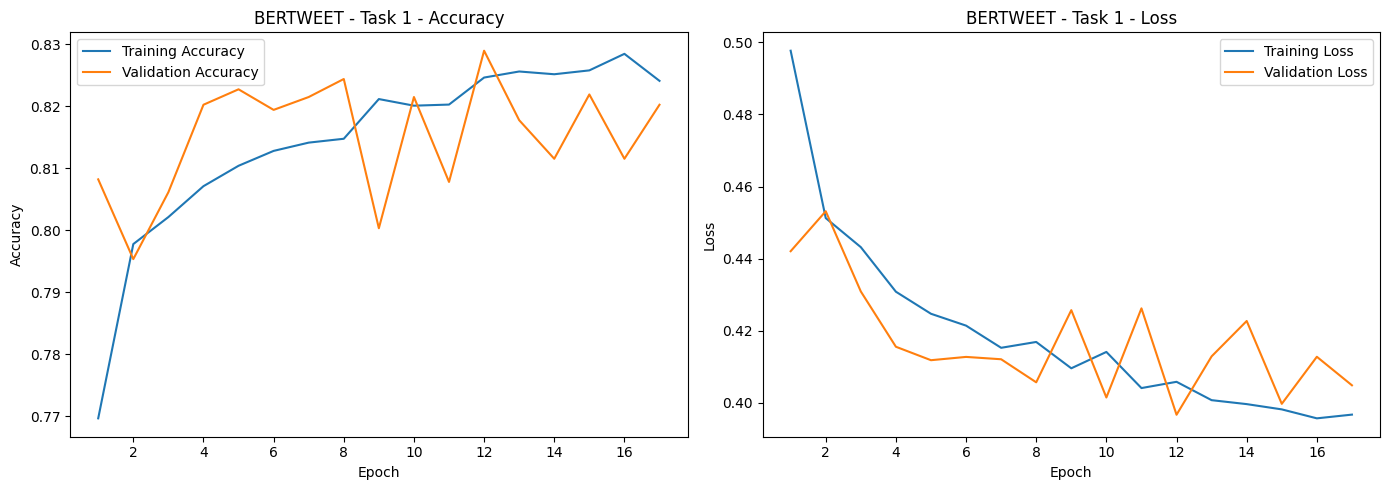

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERTWEET - Task 1
Accuracy : 0.8182
Precision: 0.7360
Recall   : 0.5593
F1-score : 0.6356


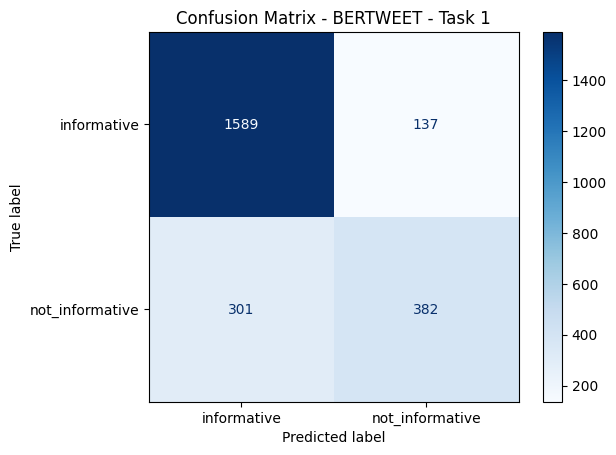


🚀 Training MLP on BERTWEET embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4641 - loss: 1.2950 - val_accuracy: 0.5795 - val_loss: 1.0271
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5922 - loss: 1.0391 - val_accuracy: 0.6218 - val_loss: 0.9449
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6156 - loss: 0.9882 - val_accuracy: 0.6413 - val_loss: 0.9202
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6279 - loss: 0.9493 - val_accuracy: 0.6459 - val_loss: 0.9161
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6361 - loss: 0.9394 - val_accuracy: 0.6555 - val_loss: 0.8855
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6404 - loss: 0.9154 - val_accuracy: 0.6443 - val_loss: 0.9198
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6348 - loss: 0.9150 - val_accuracy: 0.6633 - val_loss: 0.8576
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - ac

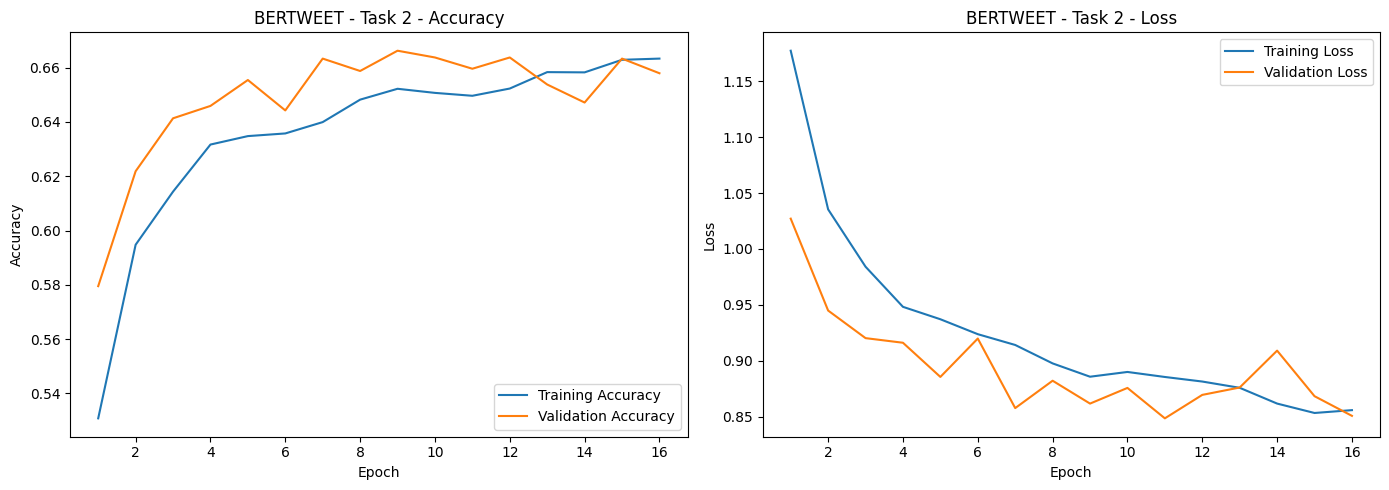

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERTWEET - Task 2
Accuracy : 0.6795
Precision: 0.6881
Recall   : 0.6000
F1-score : 0.6284


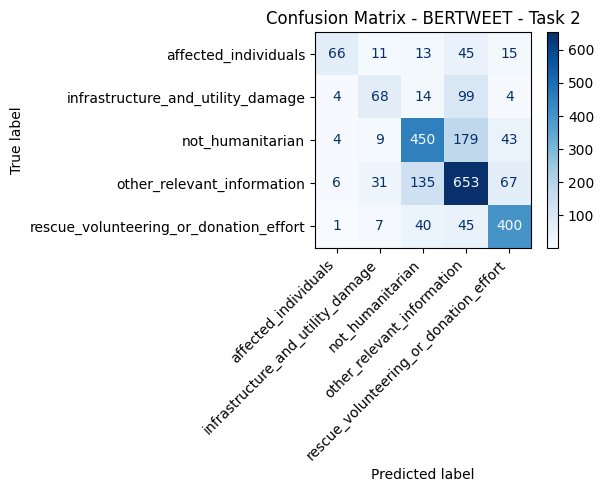

In [78]:
name = "bertweet"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1, label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2, label_encoder=le_human)

## HuggingFace Models

In [85]:
def compute_metrics(pred, is_binary=True):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids
    avg_type = 'binary' if is_binary else 'macro'
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average=avg_type, zero_division=0),
        'recall': recall_score(labels, preds, average=avg_type, zero_division=0),
        'f1': f1_score(labels, preds, average=avg_type, zero_division=0),
    }

def train_transformer_model(model_name, df_train, df_val, df_test, text_column, label_column, num_labels, task_name):
    """
    Esegue fine-tuning di un transformer Hugging Face per una classificazione testuale.

    Args:
        model_name (str): es. 'bert-base-uncased', 'vinai/bertweet-base'
        df_train, df_val, df_test (DataFrame): contengono testo e label
        text_column (str): nome colonna testo
        label_column (str): nome colonna label (interi)
        num_labels (int): 2 (binario) o N classi
        task_name (str): "Task 1" o "Task 2"
    """

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    # Tokenizzazione
    def tokenize_fn(examples):
        return tokenizer(examples[text_column], truncation=True, padding=True)

    # Conversione a Dataset Hugging Face
    ds_train = Dataset.from_pandas(df_train[[text_column, label_column]])
    ds_val = Dataset.from_pandas(df_val[[text_column, label_column]])
    ds_test = Dataset.from_pandas(df_test[[text_column, label_column]])

    ds_train = ds_train.rename_column(label_column, "label")
    ds_val = ds_val.rename_column(label_column, "label")
    ds_test = ds_test.rename_column(label_column, "label")

    ds_train = ds_train.map(tokenize_fn, batched=True)
    ds_val = ds_val.map(tokenize_fn, batched=True)
    ds_test = ds_test.map(tokenize_fn, batched=True)

    # Modello
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

    # TrainingArguments
    training_args = TrainingArguments(
        output_dir=f"./results_{task_name.replace(' ', '_').lower()}_{model_name.replace('/', '_')}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_dir='./logs',
        logging_steps=20,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=ds_train,
        eval_dataset=ds_val,
        compute_metrics=lambda p: compute_metrics(p, is_binary=(num_labels == 2)),
        tokenizer=tokenizer
    )

    # Training
    trainer.train()

    # Valutazione su test set
    test_metrics = trainer.evaluate(ds_test)
    print(f"\n📊 Test metrics for {model_name} - {task_name}")
    for k, v in test_metrics.items():
        if k.startswith("eval_"):
            print(f"{k[5:]}: {v:.4f}")


In [86]:
text_train_df["text_info_encoded"] = train_labels_task1
text_val_df["text_info_encoded"] = val_labels_task1
text_test_df["text_info_encoded"] = test_labels_task1

text_train_df["text_human_encoded"] = train_labels_task2
text_val_df["text_human_encoded"] = val_labels_task2
text_test_df["text_human_encoded"] = test_labels_task2

text_train_df.head(5)

,tweet_text,text_info,text_human,cleaned_text_bert,cleaned_text_bertweet,text_info_encoded,text_human_encoded
0,Good to see supplies from #chinaaid reaching t...,informative,rescue_volunteering_or_donation_effort,Good to see supplies from chinaaid reaching th...,Good to see supplies from #chinaaid reaching t...,0,4
1,Harvey to Impact North Texas Construction Indu...,informative,infrastructure_and_utility_damage,Harvey to Impact North Texas Construction Indu...,Harvey to Impact North Texas Construction Indu...,0,1
2,Took granddaughters back to school in Mexico C...,not_informative,not_humanitarian,Took granddaughters back to school in Mexico C...,Took granddaughters back to school in Mexico C...,1,2
3,"NEWS: At least 200 people, including 21 childr...",informative,affected_individuals,"NEWS: At least 200 people, including 21 childr...","NEWS: At least 200 people, including 21 childr...",0,0
4,Press Release: Citizens to open additional Cat...,informative,rescue_volunteering_or_donation_effort,Press Release: Citizens to open additional Cat...,Press Release: Citizens to open additional Cat...,0,4


In [90]:
import transformers
print(transformers.__version__)
print(transformers.__file__)

4.52.4
c:\Users\mario\Desktop\Deep Learning\Progetto\multimodal-crisis-classification\deep_env\lib\site-packages\transformers\__init__.py


In [91]:
from transformers import TrainingArguments

train_transformer_model(
    model_name="vinai/bertweet-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_info_encoded",  # già label encoder
    num_labels=2,
    task_name="Task 1"
)

Map: 100%|██████████| 2409/2409 [00:02<00:00, 1081.39 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'